TensorFlow version: 2.20.0
Encoder input shape: (12000, 8)
Decoder input shape: (12000, 9)
Decoder output shape: (12000, 9)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 8, 64)     │        832 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 8)         │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 9, 64)     │        832 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 8, 128),  │     98,816 │ embedding[0][0],  │
│                     │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 9, 128),  │     98,816 │ embedding_1[0][0… │
│                     │ (None, 128),      │            │ lstm[0][1],       │
│                     │ (None, 128)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additive_attention  │ [(None, 9, 128),  │        128 │ lstm_1[0][0],     │
│ (AdditiveAttention) │ (None, 9, 8)]     │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 9, 256)    │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ additive_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 9, 13)     │      3,341 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 202,765 (792.05 KB)

 Trainable params: 202,765 (792.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.3973 - loss: 1.6852 - val_accuracy: 0.6191 - val_loss: 1.0279
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8322 - loss: 0.5490 - val_accuracy: 0.9287 - val_loss: 0.2870
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9571 - loss: 0.1969 - val_accuracy: 0.9658 - val_loss: 0.1461
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9836 - loss: 0.0986 - val_accuracy: 0.9857 - val_loss: 0.0783
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9919 - loss: 0.0605 - val_accuracy: 0.9901 - val_loss: 0.0560
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9941 - loss: 0.0440 - val_accuracy: 0.9900 - val_loss: 0.0484
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9961 - loss: 0.0333 - val_accuracy: 0.9941 - val_loss: 0.0348
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9950 - loss: 0.0323 - val_acc

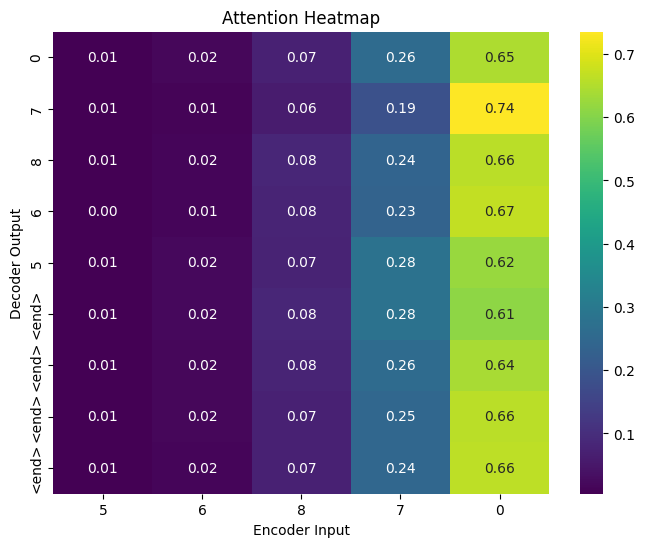

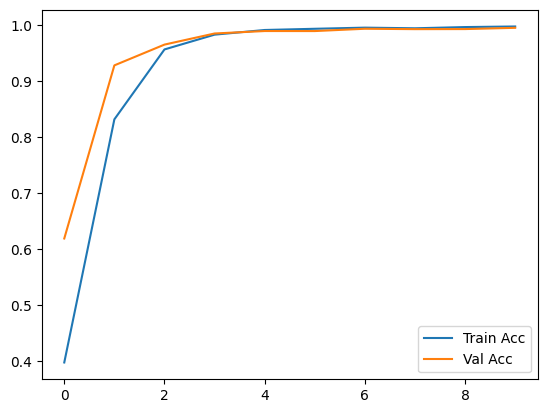

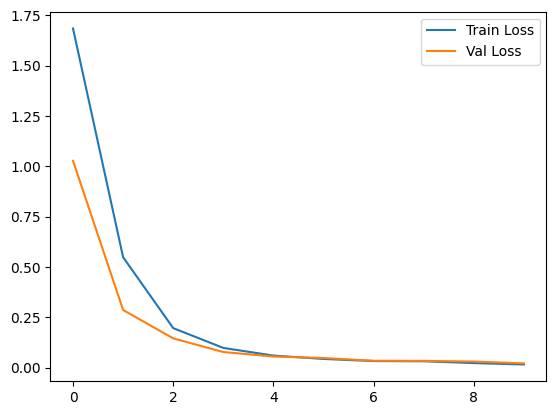

In [1]:
# ============================================================
# BLOCK 1: Import required libraries
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, AdditiveAttention, Concatenate

print("TensorFlow version:", tf.__version__)

# ============================================================
# BLOCK 2: Create toy Seq2Seq dataset
# ============================================================
PAD = 0
START = 1
END = 2

DIGIT_OFFSET = 3
VOCAB_SIZE = 13
MAX_SEQ_LEN = 8

def generate_seq2seq_data(num_samples=12000):
    encoder_inputs = []
    decoder_inputs = []
    decoder_outputs = []

    for _ in range(num_samples):
        length = np.random.randint(3, MAX_SEQ_LEN + 1)
        digits = np.random.randint(0, 10, size=length)

        source = digits + DIGIT_OFFSET
        target = source[::-1]

        enc = np.zeros(MAX_SEQ_LEN, dtype="int32")
        dec_in = np.zeros(MAX_SEQ_LEN + 1, dtype="int32")
        dec_out = np.zeros(MAX_SEQ_LEN + 1, dtype="int32")

        enc[:length] = source

        dec_in[0] = START
        dec_in[1:length + 1] = target

        dec_out[:length] = target
        dec_out[length] = END

        encoder_inputs.append(enc)
        decoder_inputs.append(dec_in)
        decoder_outputs.append(dec_out)

    return np.array(encoder_inputs), np.array(decoder_inputs), np.array(decoder_outputs)


encoder_input_data, decoder_input_data, decoder_output_data = generate_seq2seq_data()

print("Encoder input shape:", encoder_input_data.shape)
print("Decoder input shape:", decoder_input_data.shape)
print("Decoder output shape:", decoder_output_data.shape)

# ============================================================
# BLOCK 3: Token to text
# ============================================================
def token_to_text(tokens):
    text_tokens = []
    for token in tokens:
        token = int(token)
        if token == PAD:
            continue
        elif token == START:
            text_tokens.append("<start>")
        elif token == END:
            text_tokens.append("<end>")
        else:
            text_tokens.append(str(token - DIGIT_OFFSET))
    return text_tokens

# ============================================================
# BLOCK 4: Build Seq2Seq with Attention
# ============================================================
EMBED_DIM = 64
LATENT_DIM = 128

encoder_inputs = Input(shape=(MAX_SEQ_LEN,), name="encoder_inputs")
encoder_embedding = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(encoder_inputs)

encoder_outputs, state_h, state_c = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True
)(encoder_embedding)

decoder_inputs = Input(shape=(MAX_SEQ_LEN + 1,), name="decoder_inputs")
decoder_embedding = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(decoder_inputs)

decoder_outputs, _, _ = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True
)(decoder_embedding, initial_state=[state_h, state_c])

attention = AdditiveAttention()
context_vectors, attention_scores = attention(
    [decoder_outputs, encoder_outputs],
    return_attention_scores=True
)

combined = Concatenate()([decoder_outputs, context_vectors])

outputs = Dense(VOCAB_SIZE, activation="softmax")(combined)

model = Model([encoder_inputs, decoder_inputs], outputs)

attention_model = Model(
    [encoder_inputs, decoder_inputs],
    [outputs, attention_scores]
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# BLOCK 5: Train
# ============================================================
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_output_data,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# ============================================================
# BLOCK 6: Prediction
# ============================================================
def predict_sequence(sample_index):
    enc = encoder_input_data[sample_index:sample_index + 1]
    dec = decoder_input_data[sample_index:sample_index + 1]

    predictions = model.predict([enc, dec], verbose=0)
    predicted_tokens = np.argmax(predictions[0], axis=-1)

    print("Input:", token_to_text(enc[0]))
    print("Expected:", token_to_text(decoder_output_data[sample_index]))
    print("Predicted:", token_to_text(predicted_tokens))

predict_sequence(0)

# ============================================================
# BLOCK 7: Attention Heatmap
# ============================================================
def plot_attention_heatmap(sample_index):
    enc = encoder_input_data[sample_index:sample_index + 1]
    dec = decoder_input_data[sample_index:sample_index + 1]

    predictions, attention = attention_model.predict([enc, dec], verbose=0)
    predicted_tokens = np.argmax(predictions[0], axis=-1)

    input_tokens = token_to_text(enc[0])
    output_tokens = token_to_text(predicted_tokens)

    attention_matrix = attention[0][:len(output_tokens), :len(input_tokens)]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        attention_matrix,
        xticklabels=input_tokens,
        yticklabels=output_tokens,
        cmap="viridis",
        annot=True,
        fmt=".2f"
    )
    plt.xlabel("Encoder Input")
    plt.ylabel("Decoder Output")
    plt.title("Attention Heatmap")
    plt.show()

plot_attention_heatmap(0)

# ============================================================
# BLOCK 8: Plot Accuracy & Loss
# ============================================================
plt.figure()
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.show()